In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json

In [2]:
DISEASE = input("Disease: ")
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
NONE_OUTPUT_DIRECTORY = f"../output/NONE/"
DATA_DIRECTORY = OUTPUT_DIRECTORY + "leiden_results"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

In [3]:
# load selected communities
with open(f"{DATA_DIRECTORY}/result_communities.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [4]:
# concatenate all genes from selected communities
all_genes = []
for community in communities_selected:
    all_genes.extend(community)
print(all_genes)

[63, 76, 92, 103, 112, 125, 132, 156, 176, 198, 202, 220, 231, 270, 287, 328, 337, 338, 351, 353, 382, 385, 387, 388, 389, 390, 391, 392, 403, 415, 452, 483, 517, 538, 544, 550, 563, 593, 594, 600, 602, 614, 651, 654, 660, 707, 734, 741, 761, 778, 791, 795, 800, 807, 818, 875, 878, 883, 887, 890, 893, 917, 1006, 1021, 1024, 1026, 1037, 1057, 1058, 1059, 1084, 1120, 1165, 1202, 1205, 1207, 1208, 1234, 1240, 1290, 1293, 1309, 1310, 1312, 1345, 1353, 1379, 1389, 1410, 1412, 1413, 1414, 1419, 1433, 1445, 1450, 1479, 1491, 1512, 1513, 1563, 1571, 1591, 1638, 1640, 1659, 1662, 1678, 1681, 1711, 1735, 1765, 1768, 1771, 1778, 1793, 1822, 1828, 1883, 1884, 1885, 1912, 1919, 1952, 2024, 2059, 2060, 2074, 2090, 2091, 2148, 2159, 2199, 2200, 2248, 2288, 2289, 2294, 2297, 2306, 2310, 2314, 2316, 2319, 2325, 2326, 2330, 2331, 2334, 2367, 2405, 2406, 2430, 2491, 2492, 2493, 2498, 2508, 2520, 2524, 2566, 2676, 2677, 2678, 2721, 2792, 2810, 2840, 2841, 2857, 2863, 2902, 2904, 2934, 2963, 2979, 2980, 29

In [5]:
# with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
#     dgidb = json.load(file)

In [6]:
# all_genes = list(range(len(dgidb)))

In [7]:
# load eigenvalues and eigenvectors
eigenvalues = np.load(OUTPUT_DIRECTORY + "eigenvalues.npy")
eigenvectors_P = np.load(OUTPUT_DIRECTORY + "eigenvectors_P.npy")

In [8]:
# # load eigenvalues and eigenvectors single-layer
# eigenvalues_M = np.load(OUTPUT_DIRECTORY + "eigenvalues_M.npy")
# eigenvectors_P_M = np.load(OUTPUT_DIRECTORY + "eigenvectors_P_M.npy")

In [9]:
# load eigenvalues and eigenvectors single-layer
eigenvalues_M = np.load(NONE_OUTPUT_DIRECTORY + "eigenvalues.npy")
eigenvectors_P_M = np.load(NONE_OUTPUT_DIRECTORY + "eigenvectors_P.npy")

# Top eigenvalues magnitude

In [10]:
top_eigenvalues = eigenvalues[:20]
top_eigenvalues_M = eigenvalues_M[:20]

In [11]:
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


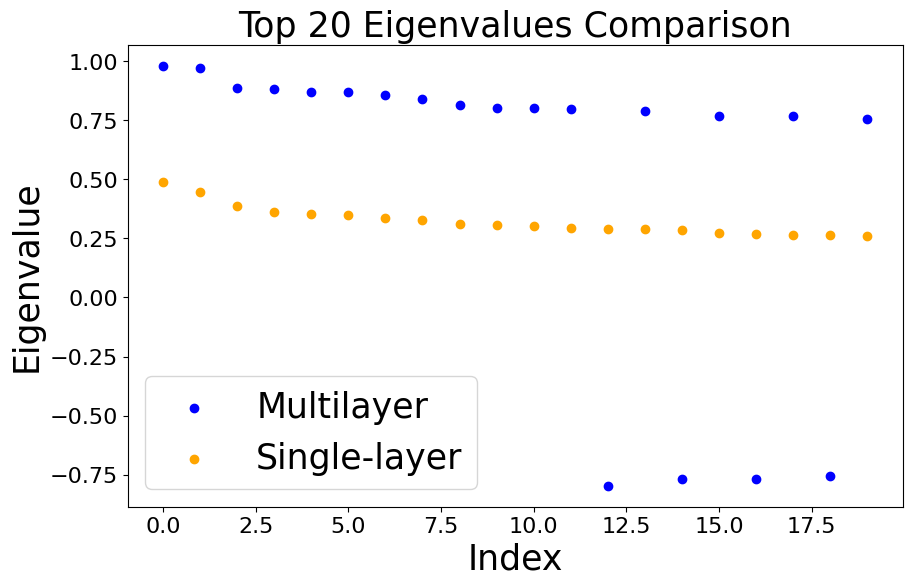

In [12]:
# plot eigenvalues comparison, dot plot, blue for multilayer, orange for single-layer
plt.figure(figsize=(10,6))
plt.scatter(range(len(top_eigenvalues)), top_eigenvalues, label="Multilayer", color='blue')
plt.scatter(range(len(top_eigenvalues_M)), top_eigenvalues_M, label="Single-layer", color='orange')
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Top 20 Eigenvalues Comparison")
# put legend outside the plot
plt.legend()

# 2D eigenvalues embedding plots

In [13]:
lambda1,lambda2 = eigenvalues[1],eigenvalues[2]
phi1,phi2 = eigenvectors_P[:,1],eigenvectors_P[:,2]

In [14]:
def embedding(gene_idx,t):
    return np.array([(lambda1**t)*phi1[gene_idx], 
                     (lambda2**t)*phi2[gene_idx]])

In [15]:
embeddings = np.array([embedding(gene_idx, t=6) for gene_idx in all_genes])
print(embeddings)

[[ 1.09605383e-01  5.35345022e-05]
 [ 4.96180707e-02 -6.85021513e-05]
 [ 1.08537142e-01  4.29760113e-05]
 ...
 [-1.89166624e-03 -1.40317739e-04]
 [-1.82814806e-03  2.99604659e-05]
 [-1.97235002e-03 -1.64894327e-04]]


In [16]:
x,y=embeddings[:,0],embeddings[:,1]

In [17]:
# # create normal scatter plot using x,y
# plt.figure(figsize=(6,5))
# plt.scatter(x, y)

In [18]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import DBSCAN

# # x, y: 1D arrays of length N
# XY = np.c_[x, y]

# # 1) standardize for clustering stability (DBSCAN is distance-based)
# Z = StandardScaler().fit_transform(XY)

# # 2) DBSCAN: tune eps/min_samples a bit
# #    - eps smaller => more/smaller clusters
# #    - min_samples larger => ignores tiny specks as noise
# db = DBSCAN(eps=0.12, min_samples=30)   # try eps: 0.08~0.25
# labels = db.fit_predict(Z)

# # cluster sizes (exclude noise = -1)
# uniq, counts = np.unique(labels, return_counts=True)
# order = uniq[np.argsort(counts)[::-1]]

# # keep only clusters you care about (e.g., top K by size, excluding noise)
# K = 12
# cluster_ids = [c for c in order if c != -1][:K]

# print("num clusters (excl noise):", np.sum(uniq != -1))
# print("noise points:", np.sum(labels == -1))
# print("top cluster sizes:", [(c, np.sum(labels==c)) for c in cluster_ids[:5]])

# # 3) density plots (one panel per cluster)
# n = len(cluster_ids)
# cols = 4
# rows = int(np.ceil(n / cols))

# fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
# axes = np.ravel(axes)

# for ax, cid in zip(axes, cluster_ids):
#     m = labels == cid
#     ax.hexbin(x[m], y[m], gridsize=80, norm=colors.LogNorm())
#     ax.set_title(f"cluster {cid}  (n={m.sum()})")
#     ax.set_xlabel("eig dim 1")
#     ax.set_ylabel("eig dim 2")

#     # local zoom to that cluster (with a small padding)
#     xlo, xhi = np.percentile(x[m], [1, 99])
#     ylo, yhi = np.percentile(y[m], [1, 99])
#     pad_x = 0.05 * (xhi - xlo + 1e-12)
#     pad_y = 0.05 * (yhi - ylo + 1e-12)
#     ax.set_xlim(xlo - pad_x, xhi + pad_x)
#     ax.set_ylim(ylo - pad_y, yhi + pad_y)

# # turn off unused axes
# for ax in axes[len(cluster_ids):]:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()
